# 02 -- EDA & Feature Engineering

Explore the Statcast data visually and build features for the Bayesian model.

**Goal:** Understand what the data looks like before asking a model to learn from it. Every feature we create has a baseball reason behind it, not just a statistical one.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import get_data
from src.features import (
    add_platoon_advantage, add_count_leverage,
    add_stuff_composite, add_location_zone,
    add_base_state, build_model_matrix,
)
from src.visualize import (
    pitch_heatmap, movement_profile, count_leverage_chart,
)

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

In [2]:
df = get_data(year=2025)
print(f"{len(df):,} pitches loaded")

709,144 pitches loaded


## Pitch Physics Distributions

Before engineering anything, look at the raw physics. Velocity, spin, and movement tell you what a pitch IS. The model needs to see these in a useful form.

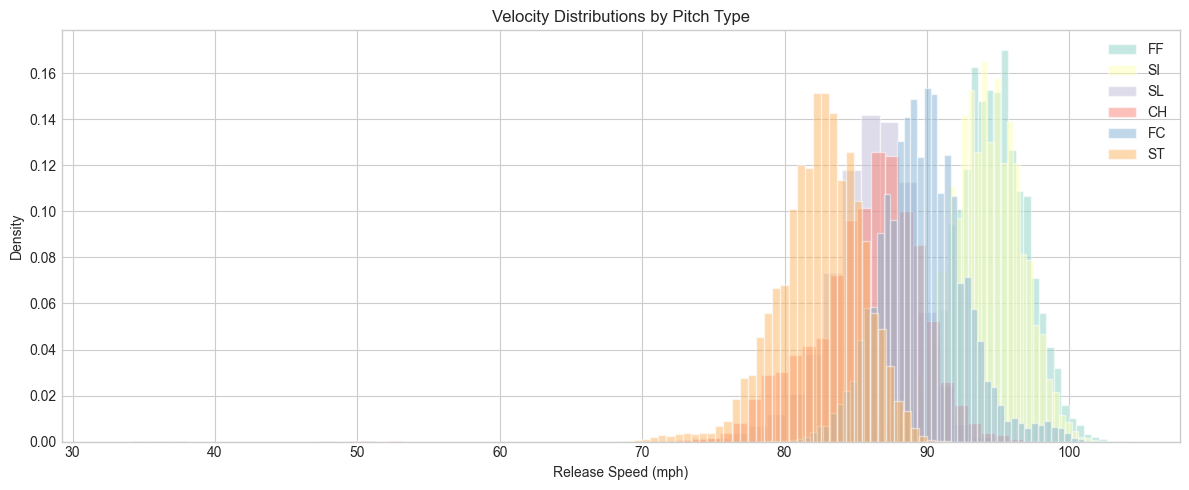

In [3]:
# Velocity distributions by pitch type
fig, ax = plt.subplots(figsize=(12, 5))
top_types = df["pitch_type"].value_counts().head(6).index
for pt in top_types:
    sub = df[df["pitch_type"] == pt]
    ax.hist(sub["release_speed"], bins=50, alpha=0.5, label=pt, density=True)
ax.set_xlabel("Release Speed (mph)")
ax.set_ylabel("Density")
ax.set_title("Velocity Distributions by Pitch Type")
ax.legend()
plt.tight_layout()
plt.show()

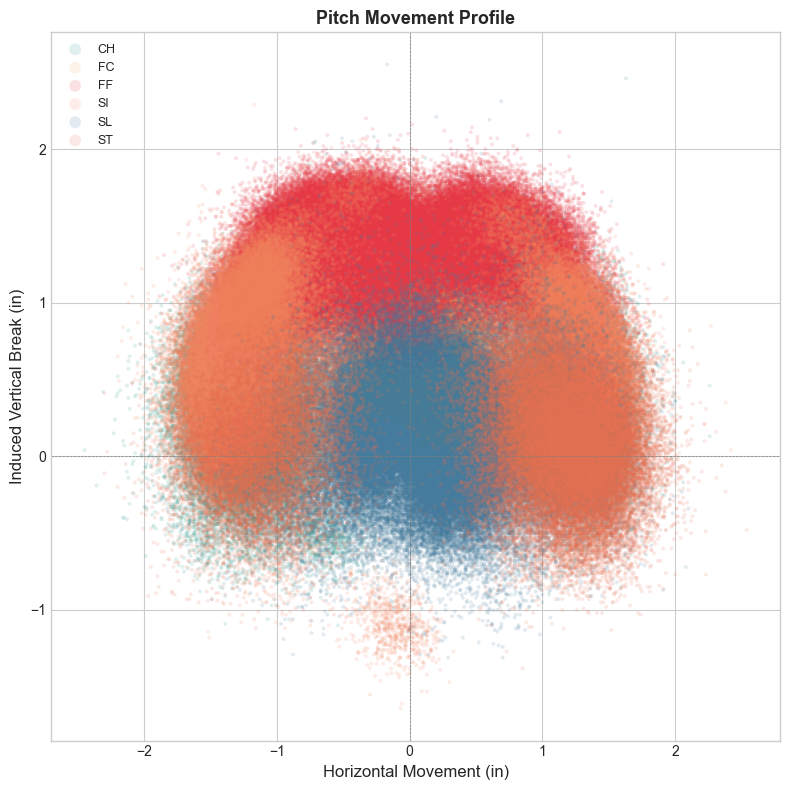

In [4]:
# Movement profiles -- the classic Baseball Savant plot
fig = movement_profile(df, pitch_types=list(top_types))
plt.show()

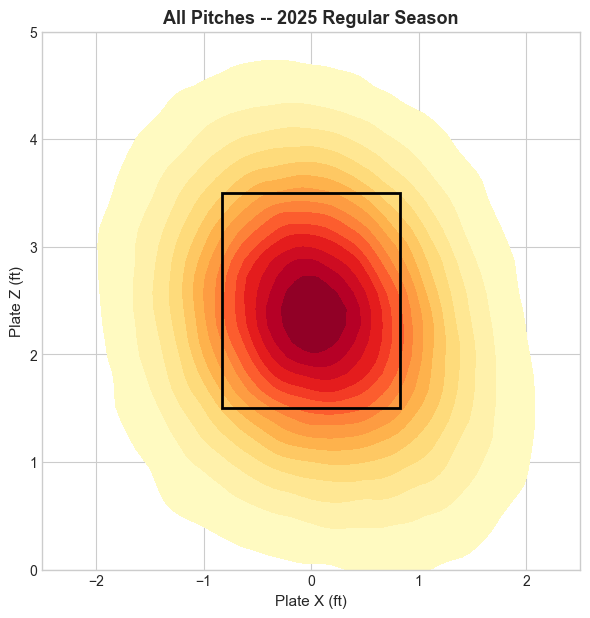

In [5]:
# Pitch location heatmap -- all pitches
fig = pitch_heatmap(df, title="All Pitches -- 2025 Regular Season")
plt.show()

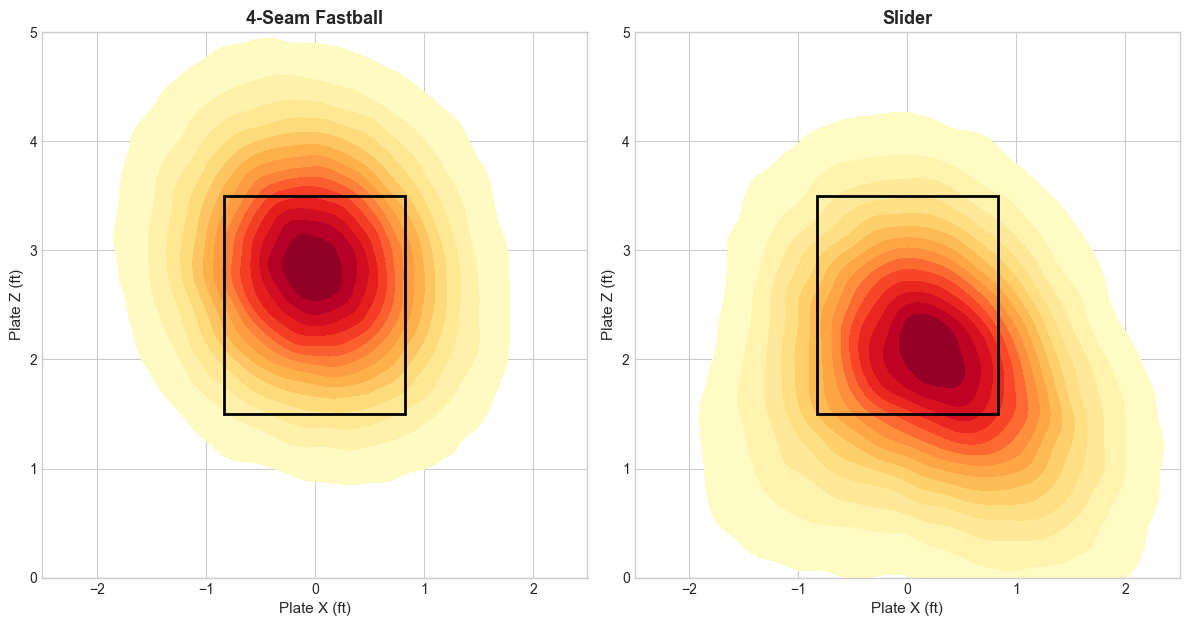

In [6]:
# Heatmap by pitch type (fastball vs. slider)
fig, axes = plt.subplots(1, 2, figsize=(12, 7))
pitch_heatmap(df, pitch_type="FF", ax=axes[0], title="4-Seam Fastball")
pitch_heatmap(df, pitch_type="SL", ax=axes[1], title="Slider")
plt.tight_layout()
plt.show()

## Count Leverage

Not all counts are equal. 0-2 is a pitcher's paradise. 3-1 is a hitter's dream. The count encodes leverage, and delta_run_exp reflects it.

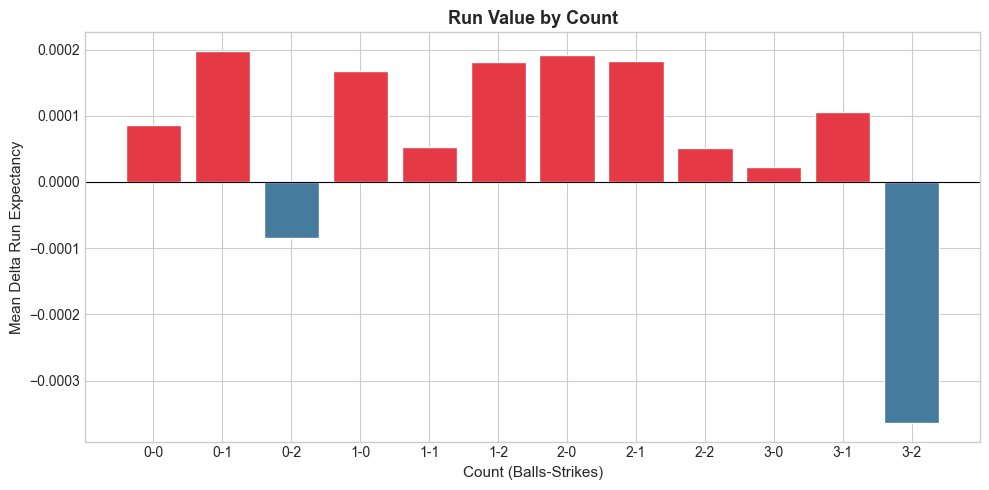

In [7]:
fig = count_leverage_chart(df)
plt.show()

## Feature Engineering

Now we transform raw columns into model-ready features. Each one has a baseball rationale.

In [8]:
# Platoon advantage
df_feat = add_platoon_advantage(df)

# Does platoon advantage actually show up in the data?
platoon_effect = df_feat.groupby("platoon_adv")["delta_run_exp"].mean()
print("Mean delta_run_exp by platoon advantage:")
print(f"  No advantage (0): {platoon_effect[0]:.4f}")
print(f"  Advantage (1):    {platoon_effect[1]:.4f}")
print(f"  Difference:       {platoon_effect[1] - platoon_effect[0]:.4f}")

Mean delta_run_exp by platoon advantage:
  No advantage (0): 0.0016
  Advantage (1):    -0.0018
  Difference:       -0.0034


In [9]:
# Stuff composite
df_feat = add_stuff_composite(df_feat)

# Does stuff composite correlate with outcomes?
correlation = df_feat["stuff_composite"].corr(df_feat["delta_run_exp"])
print(f"Stuff composite vs delta_run_exp correlation: {correlation:.4f}")
print("(Negative = higher stuff = lower run value for hitter = good for pitcher)")

Stuff composite vs delta_run_exp correlation: -0.0163
(Negative = higher stuff = lower run value for hitter = good for pitcher)


In [10]:
# Location zones
df_feat = add_location_zone(df_feat)

zone_means = df_feat.groupby("zone")["delta_run_exp"].agg(["mean", "count"])
print("\nDelta run exp by location zone:")
print(zone_means.round(4).to_string())


Delta run exp by location zone:
         mean   count
zone                 
chase  0.0008  132553
edge  -0.0302  171744
heart -0.0112  183481
waste  0.0325  221366


In [11]:
# Full pipeline
df_model, scaler = build_model_matrix(df)

print(f"\nModel matrix: {df_model.shape}")
print(f"Pitchers: {df_model.attrs.get('n_pitchers', df_model['pitcher_idx'].nunique())}")
print(f"\nFeature columns (standardized):")
for col in df_model.attrs.get('continuous_cols', []):
    print(f"  {col}: mean={df_model[col].mean():.2f}, std={df_model[col].std():.2f}")


Model matrix: (707384, 46)
Pitchers: 873

Feature columns (standardized):
  release_speed: mean=0.00, std=1.00
  release_spin_rate: mean=-0.00, std=1.00
  pfx_x: mean=-0.00, std=1.00
  pfx_z: mean=0.00, std=1.00
  plate_x: mean=-0.00, std=1.00
  plate_z: mean=-0.00, std=1.00
  stuff_composite: mean=0.00, std=1.00
  total_movement: mean=0.00, std=1.00
  count_leverage: mean=0.00, std=1.00


## Correlation Matrix

Check for multicollinearity before modeling. If two features are highly correlated, one of them is noise.

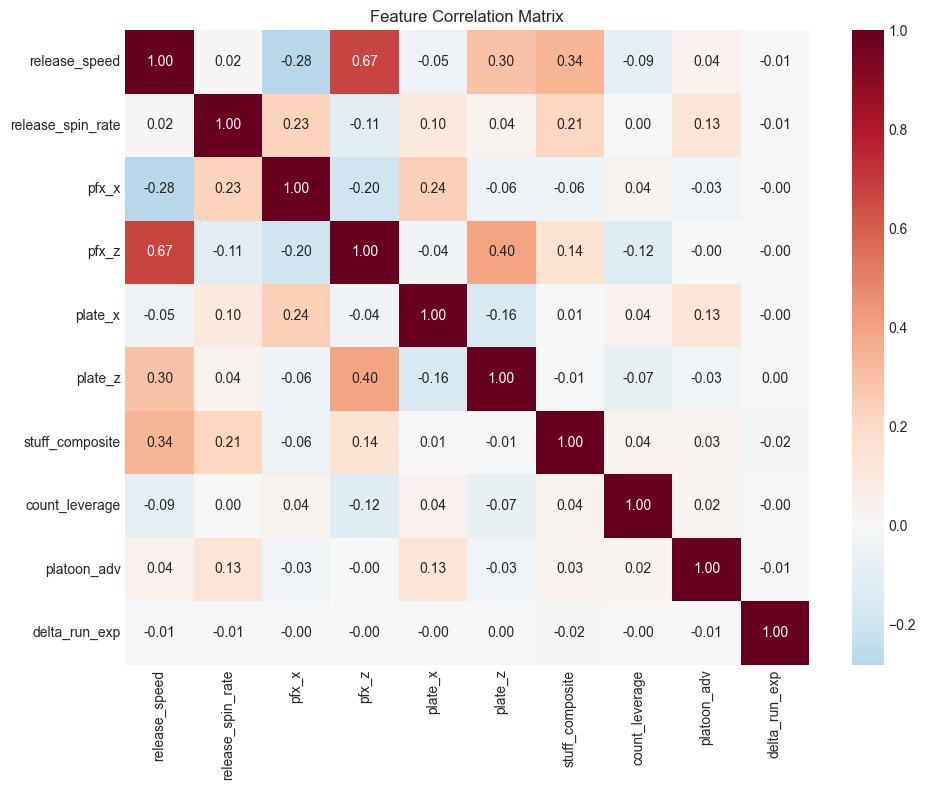

In [12]:
model_cols = [
    "release_speed", "release_spin_rate", "pfx_x", "pfx_z",
    "plate_x", "plate_z", "stuff_composite", "count_leverage",
    "platoon_adv", "delta_run_exp",
]
available = [c for c in model_cols if c in df_model.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_model[available].corr(),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    ax=ax,
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Summary

Features engineered and validated:
- **Platoon advantage**: Same-hand matchup binary flag. Shows up in the data.
- **Count leverage**: Numeric encoding of count state. Strong relationship with outcomes.
- **Stuff composite**: Z-scored velocity + movement within pitch type.
- **Location zones**: Heart / edge / chase / waste classification.
- **Base state**: 0-7 integer encoding of runners on base.
- **Pitcher index**: Contiguous 0-indexed IDs for the hierarchical model.

All continuous features standardized. Ready for the Bayesian model.

Next: `03_bayesian_model.ipynb` -- the centerpiece.